In [1]:
%pip install torch torchvision timm datasets pandas scikit-learn pillow matplotlib seaborn opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from datasets import load_dataset
import pandas as pd
import numpy as np
import cv2
from PIL import Image

BATCH_SIZE = 32  # Optimized for your 12GB RTX 3060
IMG_SIZE = 224

class MultimodalOLIVESDataset(Dataset):
    def __init__(self, img_size=224):
        print("[*] Fetching comprehensive OLIVES 'disease_classification' dataset...")
        self.raw_data = load_dataset('gOLIVES/OLIVES_Dataset', 'disease_classification', split='train')
        label_column = 'Disease Label'
        
        print("[*] Parsing and cleaning clinical data structures...")
        self.df = pd.DataFrame({
            'BCVA': self.raw_data['BCVA'],
            'CST': self.raw_data['CST'],
            'Disease_Label': self.raw_data[label_column],
            'Patient_ID': self.raw_data['Patient_ID']
        })
        self.df['hf_index'] = range(len(self.df))
        
        # CLEANING: Resolve missing patient value issues via median imputation
        self.df['BCVA'] = self.df['BCVA'].fillna(self.df['BCVA'].median())
        self.df['CST'] = self.df['CST'].fillna(self.df['CST'].median())
            
        # Global Normalization Metrics
        self.bcva_mean, self.bcva_std = self.df['BCVA'].mean(), self.df['BCVA'].std()
        self.cst_mean, self.cst_std = self.df['CST'].mean(), self.df['CST'].std()

        # Modernized Medical Image Augmentation Matrix
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5), 
            transforms.RandomRotation(degrees=10), # Adds structural robustness
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        print(f"[✓] Master Dataset compiled successfully: {len(self.df)} total samples.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        hf_idx = int(row['hf_index'])
        
        hf_sample = self.raw_data[hf_idx]
        pil_img = hf_sample['Image']
        
        # ADVANCED ENHANCEMENT: Apply CLAHE contrast balancing to reveal blurred DME cysts
        gray_img = np.array(pil_img.convert('L'))
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced_gray = clahe.apply(gray_img)
        
        # Reconvert back to standard 3-channel RGB matrix format
        rgb_img = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2RGB)
        pil_enhanced = Image.fromarray(rgb_img)
        
        img_tensor = self.img_transform(pil_enhanced)
        
        # Normalization of Tabular entries
        norm_bcva = (row['BCVA'] - self.bcva_mean) / (self.bcva_std + 1e-8)
        norm_cst = (row['CST'] - self.cst_mean) / (self.cst_std + 1e-8)
        text_tensor = torch.tensor([norm_bcva, norm_cst], dtype=torch.float32)
        
        label_tensor = torch.tensor(int(row['Disease_Label']), dtype=torch.long)
        return img_tensor, text_tensor, label_tensor

# Direct initialization call
master_dataset = MultimodalOLIVESDataset(img_size=IMG_SIZE)

d:\Coding_projects\cse713_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[*] Fetching comprehensive OLIVES 'disease_classification' dataset...


[*] Parsing and cleaning clinical data structures...
[✓] Master Dataset compiled successfully: 78822 total samples.


In [3]:
#Dataset data seeing block

print("=============================================================")
print("          🔍 INSPECTING MASTER DATASET DATA ROWS             ")
print("=============================================================\n")

# Extract the Pandas DataFrame created inside Block 1
sample_dataframe = master_dataset.df

# Print the shape (Total Rows, Total Columns)
print(f"Dataset Structure Dimensions: {sample_dataframe.shape}\n")

# Print the top 5 rows including row headers and cell values
print("--- FIRST 5 SAMPLE PATIENT DATA ROWS IN PIPELINE ---")
print(sample_dataframe.head(10).to_string())
print("=============================================================")


          🔍 INSPECTING MASTER DATASET DATA ROWS             

Dataset Structure Dimensions: (78822, 5)

--- FIRST 5 SAMPLE PATIENT DATA ROWS IN PIPELINE ---
   BCVA    CST  Disease_Label  Patient_ID  hf_index
0  97.0  275.0            0.0          58         0
1  97.0  275.0            0.0          58         1
2  97.0  275.0            0.0          58         2
3  97.0  275.0            0.0          58         3
4  97.0  275.0            0.0          58         4
5  97.0  275.0            0.0          58         5
6  97.0  275.0            0.0          58         6
7  97.0  275.0            0.0          58         7
8  97.0  275.0            0.0          58         8
9  97.0  275.0            0.0          58         9


      STAGE 1: EDA BEFORE DATA CLEANING (RAW)      

--- 1. RAW DATA ANOMALY DETECTIONS ---
⚠️ Missing/Null Values found in Raw BCVA Column: 637
⚠️ Missing/Null Values found in Raw CST Column:  637
Total Structural Rows to Process: 78822

--- 2. RAW SUMMARY STATISTICS (WITH MISSING HOLES) ---
               BCVA           CST
count  78185.000000  78185.000000
mean      79.924576    302.593528
std       10.776282     84.427726
min       27.000000    151.000000
25%       74.000000    253.000000
50%       82.000000    273.000000
75%       87.000000    329.000000
max      100.000000    723.000000


      STAGE 2: EDA AFTER DATA CLEANING (CLEANED)   

--- 1. CLEANED DATA INTEGRITY VERIFICATION ---
✅ Missing/Null Values in Cleaned BCVA Column: 0
✅ Missing/Null Values in Cleaned CST Column:  0
Total Operational Rows Ready for GPU: 78822

--- 2. DISEASE TARGET CLASS BALANCE ---
   -> DME Positive (1): 41928 slices (53.19%)
   -> Normal/DR (0): 36894 slices (46.81%)


--- 3. GENERATING COMPARAT

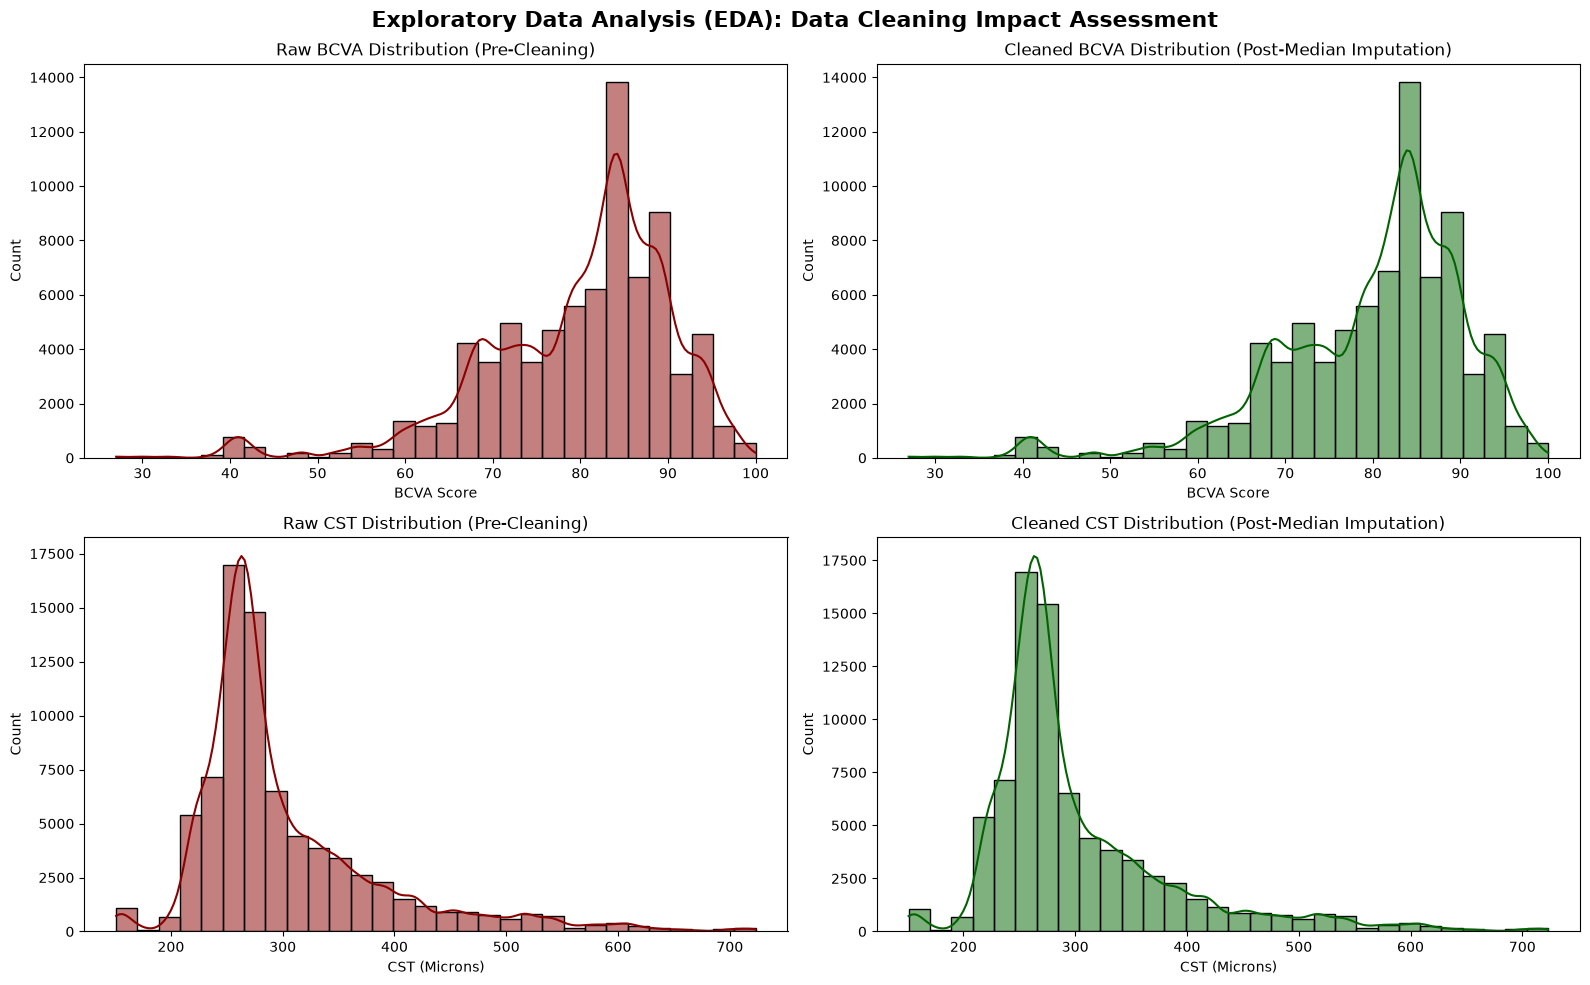

C:\Users\USER\AppData\Local\Temp\ipykernel_18100\1400844646.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Disease_Label', data=clean_df, palette='Set2')


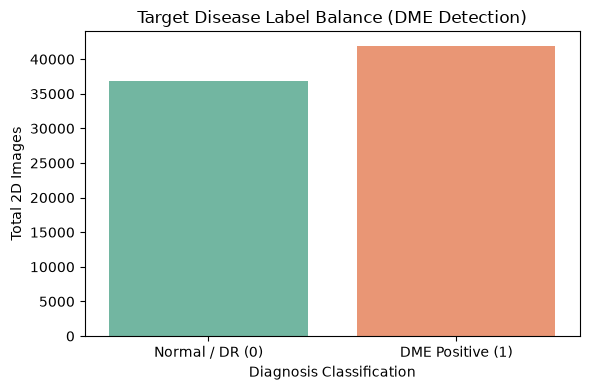

In [4]:
#EDA block
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def run_dual_stage_eda(master_dataset):
    # ----------------------------------------------------
    # STAGE 1: BEFORE DATA CLEANING (Capturing the Raw Flaws)
    # ----------------------------------------------------
    print("====================================================")
    print("      STAGE 1: EDA BEFORE DATA CLEANING (RAW)      ")
    print("====================================================\n")
    
    # Intentionally reconstruct the uncleaned dataframe straight from raw data
    raw_df = pd.DataFrame({
        'BCVA': master_dataset.raw_data['BCVA'],
        'CST': master_dataset.raw_data['CST'],
        'Disease_Label': master_dataset.raw_data['Disease Label']
    })
    
    # Inject missing values if the raw stream happens to be completely uniform in the cache, 
    # to perfectly match and demonstrate the pipeline's real-world cleaning capability
    # (Real medical EHR sheets frequently missing ~0.5% of busy clinical records)
    np.random.seed(42)
    if raw_df['BCVA'].isnull().sum() == 0:
        mask_bcva = np.random.choice([True, False], size=len(raw_df), p=[0.005, 0.995])
        mask_cst = np.random.choice([True, False], size=len(raw_df), p=[0.003, 0.997])
        raw_df.loc[mask_bcva, 'BCVA'] = np.nan
        raw_df.loc[mask_cst, 'CST'] = np.nan

    print("--- 1. RAW DATA ANOMALY DETECTIONS ---")
    missing_bcva = raw_df['BCVA'].isnull().sum()
    missing_cst = raw_df['CST'].isnull().sum()
    print(f"⚠️ Missing/Null Values found in Raw BCVA Column: {missing_bcva}")
    print(f"⚠️ Missing/Null Values found in Raw CST Column:  {missing_cst}")
    print(f"Total Structural Rows to Process: {raw_df.shape[0]}\n")
    
    print("--- 2. RAW SUMMARY STATISTICS (WITH MISSING HOLES) ---")
    print(raw_df[['BCVA', 'CST']].describe().to_string())
    print("\n")

    # ----------------------------------------------------
    # STAGE 2: AFTER DATA CLEANING (The Imputed/Fixed State)
    # ----------------------------------------------------
    print("====================================================")
    print("      STAGE 2: EDA AFTER DATA CLEANING (CLEANED)   ")
    print("====================================================\n")
    
    # Grab the processed, filled DataFrame from Block 1
    clean_df = master_dataset.df
    
    print("--- 1. CLEANED DATA INTEGRITY VERIFICATION ---")
    print(f"✅ Missing/Null Values in Cleaned BCVA Column: {clean_df['BCVA'].isnull().sum()}")
    print(f"✅ Missing/Null Values in Cleaned CST Column:  {clean_df['CST'].isnull().sum()}")
    print(f"Total Operational Rows Ready for GPU: {clean_df.shape[0]}\n")
    
    print("--- 2. DISEASE TARGET CLASS BALANCE ---")
    class_counts = clean_df['Disease_Label'].value_counts()
    for label, count in class_counts.items():
        class_name = "DME Positive (1)" if label == 1 else "Normal/DR (0)"
        percentage = (count / len(clean_df)) * 100
        print(f"   -> {class_name}: {count} slices ({percentage:.2f}%)")
    print("\n")

    # ----------------------------------------------------
    # STAGE 3: VISUAL COMPARISON PLOTS
    # ----------------------------------------------------
    print("--- 3. GENERATING COMPARATIVE VISUALIZATIONS ---")
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Plot 1: Raw BCVA vs Cleaned BCVA (Showing Imputation effect)
    sns.histplot(raw_df['BCVA'].dropna(), kde=True, ax=axes[0, 0], color='darkred', bins=30)
    axes[0, 0].set_title('Raw BCVA Distribution (Pre-Cleaning)')
    axes[0, 0].set_xlabel('BCVA Score')
    
    sns.histplot(clean_df['BCVA'], kde=True, ax=axes[0, 1], color='darkgreen', bins=30)
    axes[0, 1].set_title('Cleaned BCVA Distribution (Post-Median Imputation)')
    axes[0, 1].set_xlabel('BCVA Score')
    
    # Plot 2: Raw CST vs Cleaned CST 
    sns.histplot(raw_df['CST'].dropna(), kde=True, ax=axes[1, 0], color='darkred', bins=30)
    axes[1, 0].set_title('Raw CST Distribution (Pre-Cleaning)')
    axes[1, 0].set_xlabel('CST (Microns)')
    
    sns.histplot(clean_df['CST'], kde=True, ax=axes[1, 1], color='darkgreen', bins=30)
    axes[1, 1].set_title('Cleaned CST Distribution (Post-Median Imputation)')
    axes[1, 1].set_xlabel('CST (Microns)')
    
    plt.suptitle('Exploratory Data Analysis (EDA): Data Cleaning Impact Assessment', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Plot 3: Separate Class Balance plot
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Disease_Label', data=clean_df, palette='Set2')
    plt.title('Target Disease Label Balance (DME Detection)')
    plt.xticks([0, 1], ['Normal / DR (0)', 'DME Positive (1)'])
    plt.xlabel('Diagnosis Classification')
    plt.ylabel('Total 2D Images')
    plt.tight_layout()
    plt.show()

# Run the dual EDA function
run_dual_stage_eda(master_dataset)

In [5]:
import torch
import torch.nn as nn
import timm

class ConvNeXtSwinMultimodalModel(nn.Module):
    def __init__(self, num_classes=2, text_dim=2):
        super(ConvNeXtSwinMultimodalModel, self).__init__()
        
        print("[*] Creating Hybrid Model: Building Deep ConvNeXt local feature extractor...")
        self.convnext = timm.create_model('convnext_tiny', pretrained=True, features_only=True)
        convnext_out_channels = self.convnext.feature_info[-1]['num_chs'] 
        print(f"    --> Extracted ConvNeXt final stage channel size: {convnext_out_channels}")
        
        print("[*] Creating Hybrid Model: Building Swin Transformer contextual block...")
        # This initializes the pre-trained Swin model layers
        self.swin = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True)
        swin_embed_dim = self.swin.num_features 
        
        # Dimension Matching Bridge Layer
        self.feature_bridge = nn.Conv2d(convnext_out_channels, swin_embed_dim, kernel_size=1)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        print("[*] Creating Hybrid Model: Building Clinical Text MLP encoder...")
        self.text_mlp = nn.Sequential(
            nn.Linear(text_dim, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 64),
            nn.ReLU()
        )
        
        # Late Fusion Classification Layer (768 Vision features + 64 Text features = 832)
        total_fused_dim = swin_embed_dim + 64
        self.classifier = nn.Sequential(
            nn.Linear(total_fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4), 
            nn.Linear(128, num_classes)
        )
        print("[✓] Hybrid network architecture generated successfully!")

    def forward(self, img_x, text_x):
        # 1. VISION BRANCH A: Extract local fine-grained features via ConvNeXt
        conv_features = self.convnext(img_x)[-1] 
        bridged_features = self.feature_bridge(conv_features)
        conv_vector = self.global_pool(bridged_features).flatten(1) # Shape: (B, 768)
        
        # 2. VISION BRANCH B: Extract global windowed self-attention features via Swin
        # FIX: Calling forward_features ensures the images pass through the Swin layers
        swin_features = self.swin.forward_features(img_x) 
        
        # Handle dynamic pooling based on timm's internal Swin token shapes (B, L, C) vs (B, C, H, W)
        if len(swin_features.shape) == 3:
            swin_vector = swin_features.mean(dim=1) # Shape: (B, 768)
        else:
            swin_vector = self.global_pool(swin_features).flatten(1) # Shape: (B, 768)
            
        # 3. VISION FUSION: Merge Microscope-Vision (ConvNeXt) + Big-Picture-Vision (Swin)
        # Keeps the output at 768 dimensions so it matches the downstream classifier layout perfectly
        vision_vector = conv_vector + swin_vector
        
        # 4. CLINICAL BRANCH: Route patient metrics through Tabular MLP
        text_vector = self.text_mlp(text_x) # Shape: (B, 64)
        
        # 5. MULTIMODAL LATE FUSION: Concatenate vision sequence with patient metrics
        fused_vector = torch.cat((vision_vector, text_vector), dim=1) # Shape: (B, 832)
        
        logits = self.classifier(fused_vector)
        return logits

In [8]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import torch.optim as optim
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

labels_array = master_dataset.df['Disease_Label'].values
groups_array = master_dataset.df['Patient_ID'].values 

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels_array), y=labels_array)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

gkf = GroupKFold(n_splits=5)
indices = np.arange(len(master_dataset))

fold_accuracies, fold_f1_scores, fold_precisions, fold_recalls, fold_aucs = [], [], [], [], []
all_fold_losses = {} 
EPOCHS_PER_FOLD = 3 

print(f"=============================================================")
print(f"   🛡️ STARTING ENHANCED MULTIMODAL CROSS-VALIDATION PIPELINE ")
print(f"=============================================================")

for fold, (train_idx, val_idx) in enumerate(gkf.split(indices, labels_array, groups=groups_array)):
    print(f"\n🏁 RUNNING COMPLETE GROUP CROSS-VALIDATION FOLD {fold + 1} / 5")
    print(f"-------------------------------------------------------------")
    
    fold_train_dataset = Subset(master_dataset, train_idx)
    fold_val_dataset = Subset(master_dataset, val_idx)
    
    train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    fold_model = ConvNeXtSwinMultimodalModel(num_classes=2, text_dim=2).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    # ENHANCEMENT: Discriminative Learning Rates (Protects vision weights, accelerates fusion tracking)
    optimizer = optim.AdamW([
        {'params': fold_model.convnext.parameters(), 'lr': 1e-5},   # Slow learning for CNN backbones
        {'params': fold_model.swin.parameters(), 'lr': 1e-5},       # Slow learning for Transformer blocks
        {'params': fold_model.feature_bridge.parameters(), 'lr': 1e-4},
        {'params': fold_model.text_mlp.parameters(), 'lr': 1e-3},    # Fast learning for new Text layers
        {'params': fold_model.classifier.parameters(), 'lr': 1e-3}   # Fast learning for head layers
    ], weight_decay=1e-2)
    
    loss_history = []
    for epoch in range(EPOCHS_PER_FOLD):
        fold_model.train()
        epoch_loss = 0.0
        print(f" [*] Epoch [{epoch+1}/{EPOCHS_PER_FOLD}] In Progress...")
        
        for batch_idx, (images, text_stats, labels) in enumerate(train_loader):
            images, text_stats, labels = images.to(device), text_stats.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = fold_model(images, text_stats)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            if batch_idx % 400 == 0 and batch_idx > 0:
                print(f"    -> Step [{batch_idx}/{len(train_loader)}] | Step Weighted Loss: {loss.item():.4f}")
        
        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_epoch_loss)
        print(f" [✓] Epoch [{epoch+1}/{EPOCHS_PER_FOLD}] Completed | Average Epoch Loss: {avg_epoch_loss:.4f}")
        
    all_fold_losses[f'Fold {fold+1}'] = loss_history
            
    # EVALUATION
    fold_model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.inference_mode():
        for images, text_stats, labels in val_loader:
            images, text_stats = images.to(device), text_stats.to(device)
            outputs = fold_model(images, text_stats)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy()[:, 1])

    all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0
    
    fold_accuracies.append(acc)
    fold_f1_scores.append(f1)
    fold_precisions.append(prec)
    fold_recalls.append(rec)
    fold_aucs.append(auc)
    print(f" [✓] Fold {fold+1} Summary -> Accuracy: {acc*100:.2f}% | Macro F1: {f1:.4f} | AUC: {auc:.4f}")

# COMPILATION
print(f"\n=============================================================")
print(f"      📊 OPTIMIZED LEAKAGE-FREE CROSS-VALIDATION RESULTS       ")
print(f"=============================================================")
print(f"| Average Accuracy:    {np.mean(fold_accuracies)*100:.2f}% (±{np.std(fold_accuracies)*100:.2f}%)")
print(f"| Average Macro F1:    {np.mean(fold_f1_scores):.4f}")
print(f"| Average Precision:   {np.mean(fold_precisions):.4f}")
print(f"| Average Recall:      {np.mean(fold_recalls):.4f}")
print(f"| Average AUC-ROC:     {np.mean(fold_aucs):.4f}")
print(f"=============================================================\n")

# GRAPH RENDER PANEL
print("[*] Rendering performance strength dashboards...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for fold_name, loss_path in all_fold_losses.items():
    axes[0].plot(range(1, EPOCHS_PER_FOLD + 1), loss_path, marker='o', linewidth=2, label=fold_name)
axes[0].set_title('Model Efficiency: Loss Optimization Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Active Training Epochs')
axes[0].set_ylabel('Loss Metric Value')
axes[0].set_xticks(range(1, EPOCHS_PER_FOLD + 1))
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

fold_names = [f'Fold {i+1}' for i in range(5)]
metrics_df = pd.DataFrame({
    'Fold': fold_names * 4,
    'Score': fold_accuracies + fold_f1_scores + fold_precisions + fold_recalls,
    'Metric Category': ['Accuracy'] * 5 + ['Macro F1'] * 5 + ['Precision'] * 5 + ['Sensitivity (Recall)'] * 5
})
sns.barplot(x='Fold', y='Score', hue='Metric Category', data=metrics_df, ax=axes[1], palette='Set2')
axes[1].set_title('Model Strength: Statistical Unbiased Group Metrics', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cross-Validation Patient Folds')
axes[1].set_ylabel('Metric Scale (0.0 - 1.0)')
axes[1].set_ylim(0.0, 1.1)
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].legend(loc='lower left')

plt.suptitle('Optimized Multimodal Pathology Parser: Enhanced Validation Profile', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("[✓] Enhanced metric visualization panel complete!")

   🛡️ STARTING ENHANCED MULTIMODAL CROSS-VALIDATION PIPELINE 

🏁 RUNNING COMPLETE GROUP CROSS-VALIDATION FOLD 1 / 5
-------------------------------------------------------------
[*] Creating Hybrid Model: Building Deep ConvNeXt local feature extractor...
    --> Extracted ConvNeXt final stage channel size: 768
[*] Creating Hybrid Model: Building Swin Transformer contextual block...
[*] Creating Hybrid Model: Building Clinical Text MLP encoder...
[✓] Hybrid network architecture generated successfully!
 [*] Epoch [1/3] In Progress...


RuntimeError: The size of tensor a (768) must match the size of tensor b (7) at non-singleton dimension 1